In [73]:
import sys
print(sys.executable)

C:\Users\Yash0607\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [74]:
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from datetime import datetime , date
from dateutil.relativedelta import relativedelta
from datetime import timedelta
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

warnings.filterwarnings('ignore')
%matplotlib inline

In [75]:
df = yf.download('GOOGL' , start = '2025-04-18' , end='2026-04-17')
print(df.head())
print(df.columns)
print(df.index)
print(type(df.index))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker           GOOGL       GOOGL       GOOGL       GOOGL     GOOGL
Date                                                                
2025-04-21  147.159714  148.435289  145.595147  148.365539  26049100
2025-04-22  150.946594  151.664107  148.026711  148.375508  26971800
2025-04-23  154.813202  156.985662  153.278515  155.072298  31128800
2025-04-24  158.729614  159.038541  155.251668  155.610425  45894000
2025-04-25  161.400360  165.526054  160.483526  164.499614  56034000
MultiIndex([( 'Close', 'GOOGL'),
            (  'High', 'GOOGL'),
            (   'Low', 'GOOGL'),
            (  'Open', 'GOOGL'),
            ('Volume', 'GOOGL')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24',
               '2025-04-25', '2025-04-28', '2025-04-29', '2025-04-30',
               '2025-05-01', '2025-05-02',
               ...
               '2026-04-02', '2026-04-06

In [76]:
df.columns = df.columns.get_level_values(0) if isinstance(df.columns , pd.MultiIndex)else df.columns
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df = df.dropna()
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-21,147.159714,148.435289,145.595147,148.365539,26049100
2025-04-22,150.946594,151.664107,148.026711,148.375508,26971800
2025-04-23,154.813202,156.985662,153.278515,155.072298,31128800
2025-04-24,158.729614,159.038541,155.251668,155.610425,45894000
2025-04-25,161.400360,165.526054,160.483526,164.499614,56034000
...,...,...,...,...,...
2026-04-10,317.239990,321.829987,316.320007,320.019989,19152600
2026-04-13,321.309998,321.630005,315.470001,317.140015,18866400
2026-04-14,332.910004,333.290009,323.750000,324.790009,27721400


In [77]:
from statsmodels.tsa.stattools import adfuller
ts = df['Close'].dropna()
res = adfuller(ts)
print('ADF Statistics' , res[0])    
print('p values' , res[1])
d = 0
while True:
    if(res[1]<=0.05):
        print(f'Stationary achieved' , res[1])
        break 
    d+=1
    ts = df['Close'].diff().dropna()
    res = adfuller(ts)
    print(f'--- Differencing Level: {d} ---')
    print(f'ADF Statistic: {res[0]}')
    print(f'p-value: {res[1]}')
    
# d = 1


ADF Statistics -0.970631699288788
p values 0.7638244716968936
--- Differencing Level: 1 ---
ADF Statistic: -14.417022339573299
p-value: 8.02757784930282e-27
Stationary achieved 8.02757784930282e-27


In [78]:
ts

Date
2025-04-22     3.786880
2025-04-23     3.866608
2025-04-24     3.916412
2025-04-25     2.670746
2025-04-28    -1.345352
                ...    
2026-04-10    -1.250000
2026-04-13     4.070007
2026-04-14    11.600006
2026-04-15     4.209991
2026-04-16    -1.100006
Name: Close, Length: 248, dtype: float64

In [79]:
ts.values , ts.index 

(array([  3.78688049,   3.86660767,   3.91641235,   2.67074585,
         -1.34535217,  -0.44842529,  -1.35531616,   2.49136353,
          2.7205658 ,   0.17939758,  -0.97663879, -11.80903625,
          2.88998413,  -1.52471924,   5.69026184,   1.06628418,
          5.81982422,  -1.40512085,   2.2223053 ,   0.3487854 ,
         -2.55114746,   4.56417847,   2.30200195,  -2.39170837,
          4.41470337,  -0.53813171,  -0.49829102,  -0.11956787,
         -2.70062256,  -2.84017944,   1.86354065,   0.1594696 ,
          5.45108032,   2.61410522,   2.50437927,  -1.24720764,
         -1.64628601,  -1.02767944,   2.09527588,  -0.81816101,
         -2.62406921,  -6.66499329,  -1.44674683,   1.57647705,
          3.90118408,   2.85357666,   4.97877502,  -2.29483032,
         -0.38912964,   2.79371643,   0.88800049,  -2.7338562 ,
         -2.42453003,   2.25492859,   0.9977417 ,   2.56422424,
          1.36691284,   0.43901062,   0.96781921,   0.60862732,
          1.47666931,   5.02867126,   1.

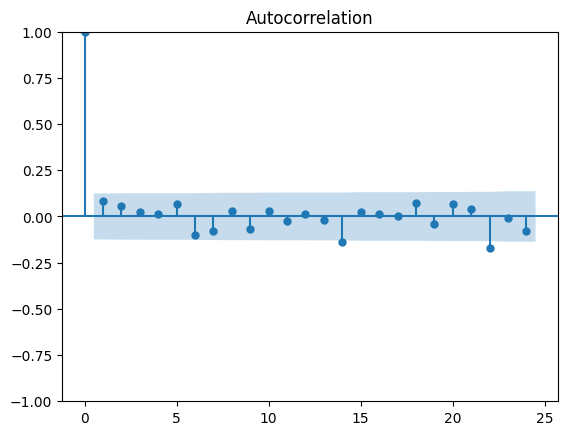

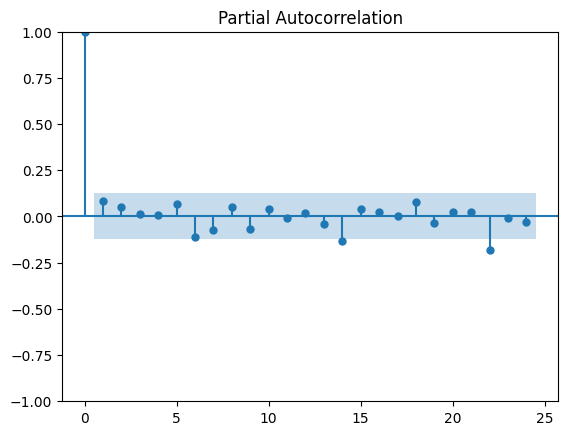

In [80]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
plot_acf(ts)
plt.show()
plot_pacf(ts)
plt.show()

In [81]:

train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]
train.index,test.index

(DatetimeIndex(['2025-04-22', '2025-04-23', '2025-04-24', '2025-04-25',
                '2025-04-28', '2025-04-29', '2025-04-30', '2025-05-01',
                '2025-05-02', '2025-05-05',
                ...
                '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-26',
                '2026-01-27', '2026-01-28', '2026-01-29', '2026-01-30',
                '2026-02-02', '2026-02-03'],
               dtype='datetime64[ns]', name='Date', length=198, freq=None),
 DatetimeIndex(['2026-02-04', '2026-02-05', '2026-02-06', '2026-02-09',
                '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13',
                '2026-02-17', '2026-02-18', '2026-02-19', '2026-02-20',
                '2026-02-23', '2026-02-24', '2026-02-25', '2026-02-26',
                '2026-02-27', '2026-03-02', '2026-03-03', '2026-03-04',
                '2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10',
                '2026-03-11', '2026-03-12', '2026-03-13', '2026-03-16',
                '2026-0

In [82]:
best_rmse = None 
best_order = None
best_rmse = float("inf")
# split data
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

for p in range(0,5):
    for q in range(0,5):
        model = ARIMA(train, order  = (p,1,q))
        res = model.fit()
        pred = res.forecast(steps=len(test))
        mse = mean_squared_error(test,pred)
        rmse = np.sqrt(mse)
        if(rmse<best_rmse):
            best_order = (p,1,q)
            best_rmse = rmse
            
print( 'Best order is : ', best_order)
print(rmse)

Best order is :  (2, 1, 0)
5.787583889875474


In [83]:
# Rolling ARIMA..

history = list(train)
predictions = []
for i in range(len(test)):
    order = (2,1,0)
    final_model = ARIMA(history , order   = (2,1,0))
    res = final_model.fit()
    final_pred = float(res.forecast()[0]) # 1 step forecast
    predictions.append(final_pred) # append the predictions .
    history.append(float(test.iloc[i])) # append the history .
    
rmse = np.sqrt(mean_squared_error(test,predictions))
print(rmse)

6.226811247498833


## Base-Line Model

In [84]:
order = (0,1,0)
baseline_model = ARIMA(train , order  = order)
res = baseline_model.fit()
baseline_pred = res.forecast(len(test))
mse = mean_squared_error(test,baseline_pred)
rmse = np.sqrt(mse)
print(rmse)

6.909932073351279


## Plot for ARIMA

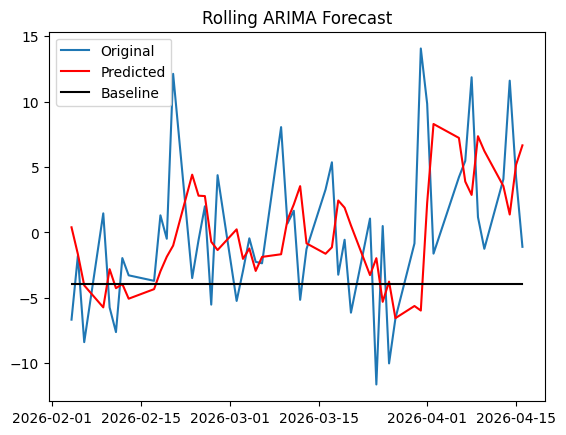

In [85]:
plt.plot(test.index,test, label = 'Original')
plt.plot(test.index,predictions, label = 'Predicted' , color ='red')
plt.plot(test.index,baseline_pred, label = 'Baseline' , color ='black')
plt.legend()
plt.title('Rolling ARIMA Forecast')
plt.show()

In [86]:
test

Date
2026-02-04    -6.665283
2026-02-05    -1.788757
2026-02-06    -8.384094
2026-02-09     1.458984
2026-02-10    -5.735992
2026-02-11    -7.614624
2026-02-12    -1.958618
2026-02-13    -3.277679
2026-02-17    -3.697418
2026-02-18     1.309082
2026-02-19    -0.479645
2026-02-20    12.121460
2026-02-23    -3.487549
2026-02-24    -0.589569
2026-02-25     1.998566
2026-02-26    -5.516083
2026-02-27     4.376923
2026-03-02    -5.236359
2026-03-03    -2.937927
2026-03-04    -0.449646
2026-03-05    -2.248444
2026-03-06    -2.358337
2026-03-09     8.049988
2026-03-10     0.680023
2026-03-11     1.660004
2026-03-12    -5.150024
2026-03-13    -1.269989
2026-03-16     3.279999
2026-03-17     5.360016
2026-03-18    -3.230011
2026-03-19    -0.559998
2026-03-20    -6.130005
2026-03-23     1.059998
2026-03-24   -11.619995
2026-03-25     0.489990
2026-03-26   -10.009979
2026-03-27    -6.580017
2026-03-30    -0.839996
2026-03-31    14.059998
2026-04-01     9.830017
2026-04-02    -1.620026
2026-04-06 

## ARIMA PREDICTION for 30 Days

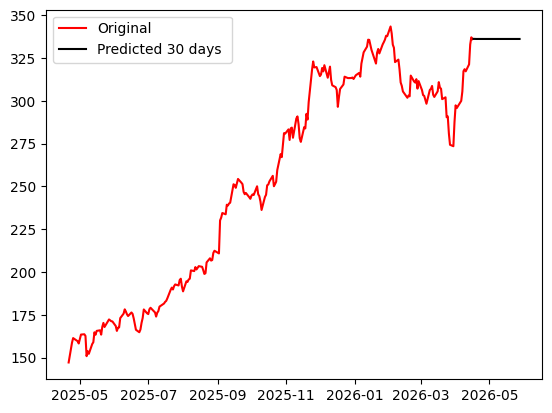

In [87]:
series =  df['Close'].dropna()
# model_30 = ARIMA(series , order = (2,1,0))
# res = model_30.fit()
# forecasst_30 = res.forecast(steps = 30) 
history = list(df['Close'].dropna())
predictions_30 = []

order = (2,1,0)   # or your best_order

for i in range(30):
    model = ARIMA(history, order=order)
    res = model.fit()

    yhat = float(res.forecast()[0])
    predictions_30.append(yhat)

    history.append(yhat)   
future_index = pd.date_range(
    start=series.index[-1],
    periods=31,
    freq='B' 
)[1:]

plt.plot(series.index,series, label = 'Original' , color = 'red')
plt.plot(future_index, predictions_30,  label = 'Predicted 30 days ' , color = 'Black')
plt.legend()
plt.show()  

In [88]:
len(predictions_30)

30

In [89]:
len(df['Close']) , len(test) , len(train)

(249, 50, 198)

## LSTM


In [90]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-04-21,147.159714,148.435289,145.595147,148.365539,26049100
2025-04-22,150.946594,151.664107,148.026711,148.375508,26971800
2025-04-23,154.813202,156.985662,153.278515,155.072298,31128800
2025-04-24,158.729614,159.038541,155.251668,155.610425,45894000
2025-04-25,161.400360,165.526054,160.483526,164.499614,56034000
...,...,...,...,...,...
2026-04-10,317.239990,321.829987,316.320007,320.019989,19152600
2026-04-13,321.309998,321.630005,315.470001,317.140015,18866400
2026-04-14,332.910004,333.290009,323.750000,324.790009,27721400


In [91]:
from sklearn.preprocessing import MinMaxScaler
def create_LSTM_sequences(df, window = 3):
    x = [] 
    y = []
    sequences = len(df) - window
    for i in range(sequences):
     x.append(df[i:i+window])
     y.append(df[i+window])     
    return np.array(x),np.array(y) 

def split(df,ratio=0.8):
    ts = pd.Series(df)
    train_size = int(len(ts) * ratio)
    train, test = ts[:train_size], ts[train_size:]
    return train,test 

def scaler(df,ratio=0.8):
    train,test = split(df,ratio)
    train =  train.values.reshape(-1,1)
    test = test.values.reshape(-1,1)
    sc = MinMaxScaler(feature_range=(0,1))
    train_scaled = sc.fit_transform(train)
    test_scaled = sc.transform(test)
    return train_scaled , test_scaled ,sc

def inverse_scale(df,sc):
   return sc.inverse_transform(df.reshape(-1,1)).flatten()


def train_lstm(train,test,window=3,epochs=100,batch_size=32,units=50):
    X_train, y_train = create_LSTM_sequences(train, window=window)
    X_test, y_test = create_LSTM_sequences(test, window=window)
    model = Sequential([
        LSTM(units, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    #  Train on train set
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Inverse transform both for actual prices

    return model , y_pred , y_test
    
    

In [92]:
series

Date
2025-04-21    147.159714
2025-04-22    150.946594
2025-04-23    154.813202
2025-04-24    158.729614
2025-04-25    161.400360
                 ...    
2026-04-10    317.239990
2026-04-13    321.309998
2026-04-14    332.910004
2026-04-15    337.119995
2026-04-16    336.019989
Name: Close, Length: 249, dtype: float64

In [93]:
train_scaled, test_scaled, sc = scaler(series)
model,y_pred, y_test = train_lstm(train_scaled, test_scaled)
y_test_prices = inverse_scale(y_test,sc)
y_pred_prices = inverse_scale(y_pred,sc)
y_pred_prices
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_prices, y_pred_prices))
print(f"RMSE: {rmse:.2f}")


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2493
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1669 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1000 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0525 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0249 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0165 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0175 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0150 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0115 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0096 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0083 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0068 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0056 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 
Epoch 16/100
7/7 ━━━

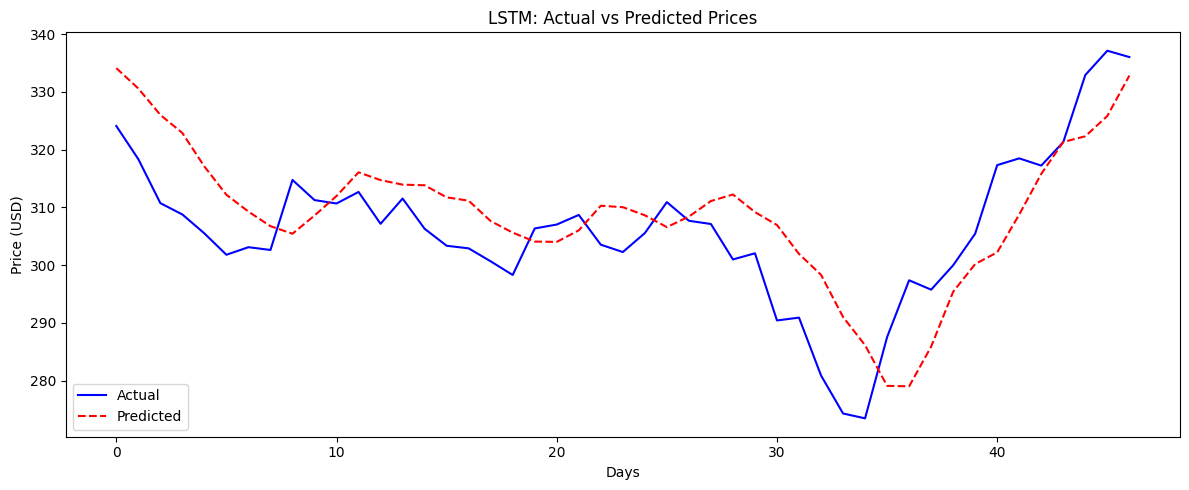

In [94]:
import matplotlib.pyplot as plt

def plot_predictions(y_test_prices, y_pred_prices):
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_prices, label='Actual', color='blue')
    plt.plot(y_pred_prices, label='Predicted', color='red', linestyle='--')
    plt.title('LSTM: Actual vs Predicted Prices')
    plt.xlabel('Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_predictions(y_test_prices, y_pred_prices)


In [95]:
train,test,sc = scaler(series)
model,y_pred, y_test = train_lstm(train, test)
y_test_prices = inverse_scale(y_test,sc).reshape(-1,1).flatten()
y_pred_prices = inverse_scale(y_pred,sc).reshape(-1,1).flatten()

# last 3 days data as input
def forecast_future_price(model,last_sequence,sc,days=30,window=3):
     
    sequence = last_sequence
    # 30 Days Forecasting Prices.
    predictions = []
    for i in range(days):
        # reshape input sequence , predict next value. append the predicted value to array , drop the old value and append new value into the existing sequence.
        input = sequence.reshape(1,3,1)
        next_val = model.predict(input,verbose=0)[0][0] #the first value
        predictions.append(next_val)
        sequence = np.append(sequence[1:], [[next_val]],axis=0)#drop old value(the first one drop it) and append new value
        
    predictions = np.array(predictions).reshape(-1,1)# reshape the predictions for inverse transform
    future_prices = sc.inverse_transform(predictions)
    return future_prices.flatten()
last_sequence = test[-3:].copy()
future_prices = forecast_future_price(model,last_sequence,sc)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2764
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1871 
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1154 
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0626 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0292 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0183 
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0172 
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0162 
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0129 
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0107 
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0091 
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0078 
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 
Epoch 14/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 
Epoch 15/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0046 
Epoch 16/100
7/7 ━━━

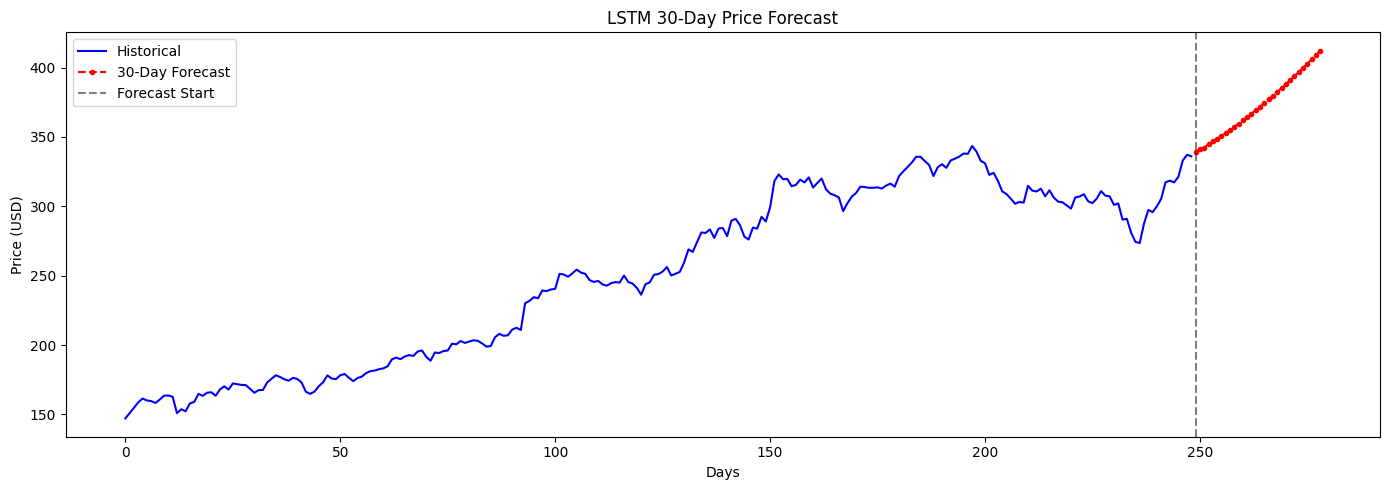

In [96]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_future_forecast(series, future_prices, days=30):
    plt.figure(figsize=(14, 5))
    
    # Plot historical prices
    plt.plot(series.values, label='Historical', color='blue')
    
    # Plot forecast starting from where history ends
    forecast_index = range(len(series), len(series) + days)
    plt.plot(forecast_index, future_prices, label='30-Day Forecast', 
             color='red', linestyle='--', marker='o', markersize=3)
    
    # Vertical line separating history and forecast
    plt.axvline(x=len(series), color='black', linestyle='--', alpha=0.5, label='Forecast Start')
    
    plt.title('LSTM 30-Day Price Forecast')
    plt.xlabel('Days')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_future_forecast(series, future_prices)
